In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [3]:
df=sns.load_dataset('titanic')
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [9]:
cols_list=df.columns
cols_list

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='object')

In [8]:
df.dtypes

survived          int64
pclass            int64
sex              object
age             float64
sibsp             int64
parch             int64
fare            float64
embarked         object
class          category
who              object
adult_male         bool
deck           category
embark_town      object
alive            object
alone              bool
dtype: object

In [21]:
new_obj=[]
n=len(cols_list)
for i in range(0,n):
    if((df[cols_list[i]]).dtypes==object):
        new_obj.append(cols_list[i])
    elif((df[cols_list[i]]).dtypes==bool):
        new_obj.append(cols_list[i])
    elif((df[cols_list[i]]).dtypes==str):
        new_obj.append(cols_list[i])
    elif((df[cols_list[i]]).dtypes=='category'):
        new_obj.append(cols_list[i])
    else:
        continue
new_obj

['sex',
 'embarked',
 'class',
 'who',
 'adult_male',
 'deck',
 'embark_town',
 'alive',
 'alone']

In [23]:
for i in range(0,len(new_obj)):
    print(f"{new_obj[i]}\n",df[new_obj[i]].unique())
    print("\n")

sex
 ['male' 'female']


embarked
 ['S' 'C' 'Q' nan]


class
 ['Third', 'First', 'Second']
Categories (3, object): ['First', 'Second', 'Third']


who
 ['man' 'woman' 'child']


adult_male
 [ True False]


deck
 [NaN, 'C', 'E', 'G', 'D', 'A', 'B', 'F']
Categories (7, object): ['A', 'B', 'C', 'D', 'E', 'F', 'G']


embark_town
 ['Southampton' 'Cherbourg' 'Queenstown' nan]


alive
 ['no' 'yes']


alone
 [False  True]




In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [31]:
df['age']=df['age'].fillna(df['age'].mean(numeric_only=True))
df['age'].isna().sum()

np.int64(0)

In [36]:
df=df.dropna(subset=['embark_town','embarked'])
df.info()
df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
Index: 889 entries, 0 to 890
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     889 non-null    int64   
 1   pclass       889 non-null    int64   
 2   sex          889 non-null    object  
 3   age          889 non-null    float64 
 4   sibsp        889 non-null    int64   
 5   parch        889 non-null    int64   
 6   fare         889 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        889 non-null    category
 9   who          889 non-null    object  
 10  adult_male   889 non-null    bool    
 11  embark_town  889 non-null    object  
 12  alive        889 non-null    object  
 13  alone        889 non-null    bool    
dtypes: bool(2), category(1), float64(2), int64(4), object(5)
memory usage: 86.1+ KB


survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64

In [44]:
copy_df=df.copy()
cols_list=list(copy_df.columns)

In [45]:
new_obj1=[]
n=len(cols_list)
for i in range(0,n):
    if((df[cols_list[i]]).dtypes==object):
        new_obj1.append(cols_list[i])
    elif((df[cols_list[i]]).dtypes==bool):
        new_obj1.append(cols_list[i])
    elif((df[cols_list[i]]).dtypes==str):
        new_obj1.append(cols_list[i])
    elif((df[cols_list[i]]).dtypes=='category'):
        new_obj1.append(cols_list[i])
    else:
        continue
new_obj1

['sex',
 'embarked',
 'class',
 'who',
 'adult_male',
 'embark_town',
 'alive',
 'alone']

In [47]:
from sklearn.preprocessing import LabelEncoder
for i in range(0,len(new_obj1)):
    lb=LabelEncoder()
    copy_df[new_obj1[i]]=lb.fit_transform(copy_df[new_obj1[i]])
copy_df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,1,22.000000,1,0,7.2500,2,2,1,1,2,0,0
1,1,1,0,38.000000,1,0,71.2833,0,0,2,0,0,1,0
2,1,3,0,26.000000,0,0,7.9250,2,2,2,0,2,1,1
3,1,1,0,35.000000,1,0,53.1000,2,0,2,0,2,1,0
4,0,3,1,35.000000,0,0,8.0500,2,2,1,1,2,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,1,27.000000,0,0,13.0000,2,1,1,1,2,0,1
887,1,1,0,19.000000,0,0,30.0000,2,0,2,0,2,1,1
888,0,3,0,29.699118,1,2,23.4500,2,2,2,0,2,0,0
889,1,1,1,26.000000,0,0,30.0000,0,0,1,1,0,1,1


In [59]:
crr=copy_df.corr().round(1)
crr

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
survived,1.0,-0.3,-0.5,-0.1,-0.0,0.1,0.3,-0.2,-0.3,0.3,-0.6,-0.2,1.0,-0.2
pclass,-0.3,1.0,0.1,-0.3,0.1,0.0,-0.5,0.2,1.0,-0.2,0.1,0.2,-0.3,0.1
sex,-0.5,0.1,1.0,0.1,-0.1,-0.2,-0.2,0.1,0.1,-0.6,0.9,0.1,-0.5,0.3
age,-0.1,-0.3,0.1,1.0,-0.2,-0.2,0.1,-0.0,-0.3,0.4,0.3,-0.0,-0.1,0.2
sibsp,-0.0,0.1,-0.1,-0.2,1.0,0.4,0.2,0.1,0.1,-0.1,-0.3,0.1,-0.0,-0.6
parch,0.1,0.0,-0.2,-0.2,0.4,1.0,0.2,0.0,0.0,-0.1,-0.4,0.0,0.1,-0.6
fare,0.3,-0.5,-0.2,0.1,0.2,0.2,1.0,-0.2,-0.5,0.1,-0.2,-0.2,0.3,-0.3
embarked,-0.2,0.2,0.1,-0.0,0.1,0.0,-0.2,1.0,0.2,-0.1,0.1,1.0,-0.2,0.1
class,-0.3,1.0,0.1,-0.3,0.1,0.0,-0.5,0.2,1.0,-0.2,0.1,0.2,-0.3,0.1
who,0.3,-0.2,-0.6,0.4,-0.1,-0.1,0.1,-0.1,-0.2,1.0,-0.4,-0.1,0.3,0.0


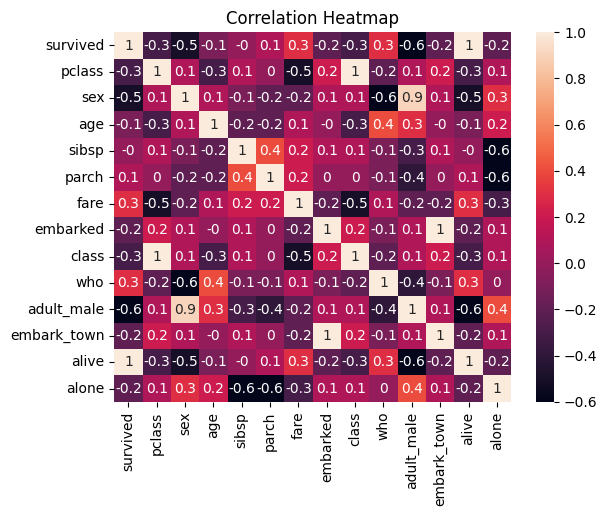

In [61]:
sns.heatmap(crr,annot=True)
plt.title("Correlation Heatmap")
plt.show()

In [66]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 889 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     889 non-null    int64   
 1   pclass       889 non-null    int64   
 2   sex          889 non-null    object  
 3   age          889 non-null    float64 
 4   sibsp        889 non-null    int64   
 5   parch        889 non-null    int64   
 6   fare         889 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        889 non-null    category
 9   who          889 non-null    object  
 10  embark_town  889 non-null    object  
 11  alone        889 non-null    bool    
dtypes: bool(1), category(1), float64(2), int64(4), object(4)
memory usage: 78.3+ KB


In [70]:
new_df=copy_df.astype(int)
new_df=new_df.drop(['adult_male','alive'],axis=1)
new_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 889 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   survived     889 non-null    int64
 1   pclass       889 non-null    int64
 2   sex          889 non-null    int64
 3   age          889 non-null    int64
 4   sibsp        889 non-null    int64
 5   parch        889 non-null    int64
 6   fare         889 non-null    int64
 7   embarked     889 non-null    int64
 8   class        889 non-null    int64
 9   who          889 non-null    int64
 10  embark_town  889 non-null    int64
 11  alone        889 non-null    int64
dtypes: int64(12)
memory usage: 90.3 KB


In [72]:
new_df.isna().sum()

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
embark_town    0
alone          0
dtype: int64

In [77]:
x=new_df.drop(['survived'],axis=1)
y=new_df['survived']

In [79]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.20,random_state=42)

In [84]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression()
model.fit(x_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [86]:
y_predict=model.predict(x_test)
y_predict

array([0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0,
       0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0,
       0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0,
       0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0,
       0, 1])

In [ ]:
from sklearn.metrics import accuracy_score
acc_sc=accuracy_score(y_test,y_predict)
print(f"The accuracy is:{acc_sc*100//1}%")

The accuracy is:80.0%
